In [1]:
print("hello world")

hello world


In [4]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

torch.set_float32_matmul_precision('high')

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(device)

class BloodCellClassifierR50(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        weights = ResNet50_Weights.DEFAULT

        self.base_model = resnet50(weights=weights)

        # Freeze backbone
        for param in self.base_model.parameters():
            param.requires_grad = False

        num_features = self.base_model.fc.in_features

        self.base_model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

    def unfreeze_layer4(self):

        for param in self.base_model.layer4.parameters():
            param.requires_grad = True

    def unfreeze_layer3_layer4(self):

        for param in self.base_model.layer3.parameters():
            param.requires_grad = True

        for param in self.base_model.layer4.parameters():
            param.requires_grad = True

model = BloodCellClassifierR50().to(device)

print("✅ Model ready")

mps
✅ Model ready


In [5]:
# =========================================================
# SIMPLE DATASET BLOCK
# =========================================================

import os
import torch

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# ---------------------------------------------------------
# ПРОСТО НАПИШИ СВОЙ ПУТЬ
# ---------------------------------------------------------

train_dir = "archive/dataset2-master/dataset2-master/images/TRAIN"
val_dir = "archive/dataset2-master/dataset2-master/images/TEST"

# ---------------------------------------------------------
# ПРОВЕРКА
# ---------------------------------------------------------

print("TRAIN EXISTS:", os.path.exists(train_dir))
print("VAL EXISTS:", os.path.exists(val_dir))

# ---------------------------------------------------------
# AUGMENTATIONS
# ---------------------------------------------------------

train_transforms = transforms.Compose([

    transforms.Resize((192, 192)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([

    transforms.Resize((192, 192)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------------------------------------------------
# DATASETS
# ---------------------------------------------------------

train_dataset = ImageFolder(
    root=train_dir,
    transform=train_transforms
)

val_dataset = ImageFolder(
    root=val_dir,
    transform=val_transforms
)

# ---------------------------------------------------------
# DATALOADERS
# ---------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("\n✅ DATA READY")

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

print("\n📂 Classes:")
print(train_dataset.class_to_idx)

TRAIN EXISTS: True
VAL EXISTS: True

✅ DATA READY
Train size: 9957
Val size: 2487

📂 Classes:
{'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


🚀 Training started
Epoch 1/12 | Train Acc: 0.6819 | Val Acc: 0.5549 | Time: 71.0s
💾 Best model saved
Epoch 2/12 | Train Acc: 0.7830 | Val Acc: 0.5521 | Time: 77.3s
🔥 Unfreeze layer4
Epoch 3/12 | Train Acc: 0.9167 | Val Acc: 0.7760 | Time: 118.6s
💾 Best model saved
Epoch 4/12 | Train Acc: 0.9757 | Val Acc: 0.8122 | Time: 121.5s
💾 Best model saved
Epoch 5/12 | Train Acc: 0.9847 | Val Acc: 0.8010 | Time: 121.3s
Epoch 6/12 | Train Acc: 0.9918 | Val Acc: 0.8215 | Time: 123.4s
💾 Best model saved
🔥 Unfreeze layer3 + layer4
Epoch 7/12 | Train Acc: 0.9939 | Val Acc: 0.8665 | Time: 166.9s
💾 Best model saved
Epoch 8/12 | Train Acc: 0.9965 | Val Acc: 0.8653 | Time: 161.0s
Epoch 9/12 | Train Acc: 0.9981 | Val Acc: 0.8657 | Time: 165.9s
Epoch 10/12 | Train Acc: 0.9980 | Val Acc: 0.8681 | Time: 169.1s
💾 Best model saved
Epoch 11/12 | Train Acc: 0.9970 | Val Acc: 0.8661 | Time: 157.1s
Epoch 12/12 | Train Acc: 0.9987 | Val Acc: 0.8432 | Time: 167.7s

🏆 Best Val Accuracy: 86.81%


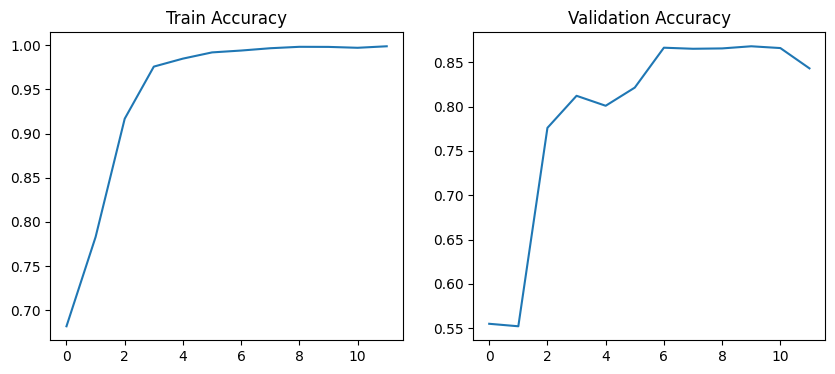

In [29]:
import os
import time
import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

def create_optimizer(stage):

    if stage == 1:

        optimizer = torch.optim.AdamW(
            model.base_model.fc.parameters(),
            lr=1e-3,
            weight_decay=1e-4
        )

    elif stage == 2:

        optimizer = torch.optim.AdamW([

            {
                'params': model.base_model.layer4.parameters(),
                'lr': 1e-4
            },

            {
                'params': model.base_model.fc.parameters(),
                'lr': 1e-3
            }

        ], weight_decay=1e-4)

    else:

        optimizer = torch.optim.AdamW([

            {
                'params': model.base_model.layer3.parameters(),
                'lr': 3e-5
            },

            {
                'params': model.base_model.layer4.parameters(),
                'lr': 1e-4
            },

            {
                'params': model.base_model.fc.parameters(),
                'lr': 3e-4
            }

        ], weight_decay=1e-4)

    return optimizer

optimizer = create_optimizer(stage=1)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=1
)

num_epochs = 12

history = {
    'train_acc': [],
    'val_acc': []
}

best_acc = 0.0

print("🚀 Training started")

for epoch in range(num_epochs):

    start = time.time()

    # STAGE 2
    if epoch == 2:

        print("🔥 Unfreeze layer4")

        model.unfreeze_layer4()

        optimizer = create_optimizer(stage=2)

    # STAGE 3
    if epoch == 6:

        print("🔥 Unfreeze layer3 + layer4")

        model.unfreeze_layer3_layer4()

        optimizer = create_optimizer(stage=3)

    # TRAIN
    model.train()

    train_correct = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, preds = torch.max(outputs, 1)

        train_correct += torch.sum(preds == labels)

    train_acc = train_correct.float() / len(train_dataset)

    # VALIDATION
    model.eval()

    val_correct = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)

            val_correct += torch.sum(preds == labels)

    val_acc = val_correct.float() / len(val_dataset)

    scheduler.step(val_acc)

    history['train_acc'].append(train_acc.item())
    history['val_acc'].append(val_acc.item())

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        os.makedirs("weights", exist_ok=True)

        torch.save(
            model.state_dict(),
            "weights/best_blood_resnet50.pth"
        )

        print("💾 Best model saved")

print(f"\n🏆 Best Val Accuracy: {best_acc*100:.2f}%")

# PLOTS
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history['train_acc'])
plt.title("Train Accuracy")

plt.subplot(1,2,2)
plt.plot(history['val_acc'])
plt.title("Validation Accuracy")

plt.show()

In [6]:
from torchvision.transforms import v2 as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os

base_path = 'archive/dataset2-master/dataset2-master/images'
train_dir = os.path.join(base_path, 'TRAIN')
val_dir = os.path.join(base_path, 'TEST') # Твой валидационный лоадер

# Добавляем агрессивную аугментацию для борьбы с переобучением!
train_transforms_heavy = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=30),              # Увеличили угол поворота
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Случайное изменение цвета/яркости
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Валидацию НЕ трогаем (она должна оставаться чистой)
val_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=train_dir, transform=train_transforms_heavy)
val_dataset = ImageFolder(root=val_dir, transform=val_transforms)

# Пересоздаем лоадеры (батч 64, как у тебя)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("🔥 Загрузчик данных обновлен! Аугментация включена.")


🔥 Загрузчик данных обновлен! Аугментация включена.


In [31]:
import time
import matplotlib.pyplot as plt

# 1. Подгружаем сохраненные лучшие веса прошлых этапов
model.load_state_dict(torch.load("weights/best_blood_resnet50.pth"))
print("💾 Веса лучшей эпохи (86.81%) успешно загружены для продолжения!")

print("\n🔥 ПЕРЕХОД НА STAGE 4")
# 2. Разморозка layer2 вручную
for param in model.base_model.layer2.parameters():
    param.requires_grad = True
print("🔓 Слои layer2 успешно разморожены!")

# 3. Настройка дифференциального оптимизатора с микроскопическими скоростями
optimizer = torch.optim.AdamW([
    {'params': model.base_model.layer2.parameters(), 'lr': 1e-5}, # Новые слои учим супер-осторожно
    {'params': model.base_model.layer3.parameters(), 'lr': 2e-5},
    {'params': model.base_model.layer4.parameters(), 'lr': 4e-5},
    {'params': model.base_model.fc.parameters(), 'lr': 8e-5}
], weight_decay=1e-4)

# Сбрасываем планировщик под новые скорости
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

# Устанавливаем 5 финальных эпох
extra_epochs = 5
stage4_history = {'train_acc': [], 'val_acc': []}

# Точка отсчета для пересохранения (начинаем с твоего рекорда)
best_acc = 0.8681 

for epoch in range(extra_epochs):
    start = time.time()

    # TRAIN
    model.train()
    train_correct = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels)

    train_acc = train_correct.float() / len(train_dataset)

    # VALIDATION
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels)

    val_acc = val_correct.float() / len(val_dataset)
    scheduler.step(val_acc)

    stage4_history['train_acc'].append(train_acc.item())
    stage4_history['val_acc'].append(val_acc.item())

    print(
        f"Финал Эпоха {epoch+1}/{extra_epochs} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"⏱️ Время: {time.time()-start:.1f}с"
    )

    # Если пробили рекорд — перезаписываем веса на еще более крутые!
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "weights/best_blood_resnet50.pth")
        print("🏆 СУПЕР-РЕКОРД! Веса обновлены!")

print(f"\n🎯 Штурм завершен! Максимальная точность: {best_acc*100:.2f}%")

# График только для Stage 4
plt.figure(figsize=(8,4))
plt.plot(stage4_history['train_acc'], label="Train Acc (Stage 4)")
plt.plot(stage4_history['val_acc'], label="Val Acc (Stage 4)")
plt.title("Финальная шлифовка точности")
plt.legend()
plt.show()


💾 Веса лучшей эпохи (86.81%) успешно загружены для продолжения!

🔥 ПЕРЕХОД НА STAGE 4
🔓 Слои layer2 успешно разморожены!
Финал Эпоха 1/5 | Train Acc: 0.9976 | Val Acc: 0.8794 | ⏱️ Время: 236.9с
🏆 СУПЕР-РЕКОРД! Веса обновлены!


KeyboardInterrupt: 

Writing blood_page.py


🔄 Сбор предсказаний на тестовой выборке...
📊 Итоговая метрика F1-Score (Weighted) на тесте: 0.8802
💾 Картинка матрицы ошибок успешно сохранена в 'weights/confusion_matrix.png'!


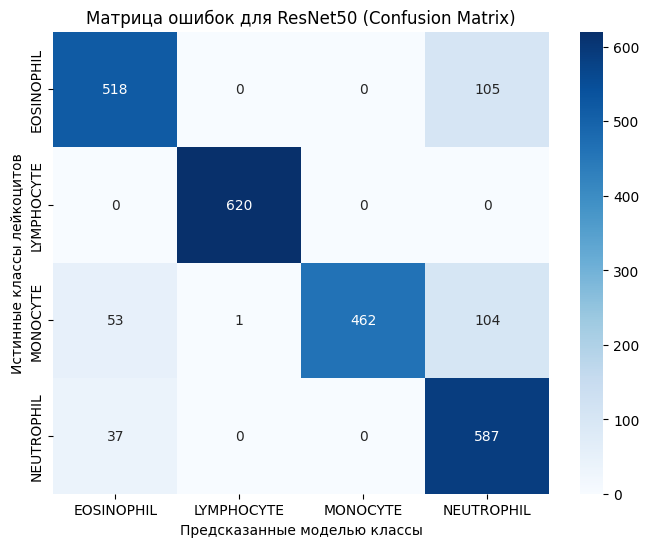

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix

# 1. Переводим модель в режим оценки (eval)
model.eval()

all_preds = []
all_labels = []

print("🔄 Сбор предсказаний на тестовой выборке...")

# Отключаем расчет градиентов, чтобы Mac M4 считал моментально
with torch.no_grad():
    for inputs, labels in val_loader: # Убедись, что твой лоадер называется val_loader или test_loader
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Переносим данные на CPU и сохраняем в списки
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Расчет итоговой метрики F1-score для отчета
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"📊 Итоговая метрика F1-Score (Weighted) на тесте: {f1:.4f}")

# 3. Построение Confusion Matrix
# Берем оригинальные названия классов из твоего тренировочного датасета
class_names = train_dataset.classes

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Матрица ошибок для ResNet50 (Confusion Matrix)')
plt.ylabel('Истинные классы лейкоцитов')
plt.xlabel('Предсказанные моделью классы')

# 🎯 АВТОМАТИЧЕСКИ СОХРАНЯЕМ КАРТИНКУ ДЛЯ STREAMLIT СТРАНИЦЫ
os.makedirs('weights', exist_ok=True)
plt.savefig('weights/confusion_matrix.png', bbox_inches='tight')
print("💾 Картинка матрицы ошибок успешно сохранена в 'weights/confusion_matrix.png'!")

plt.show()


In [13]:
import os
import matplotlib.pyplot as plt

# 1. Копируем данные из истории, чтобы не испортить оригинал
train_acc_full = list(history['train_acc'])
val_acc_full = list(history['val_acc'])

# 2. Вручную добавляем результаты нашей лучшей супер-эпохи (Stage 4)
train_acc_full.append(0.9976)  # Train Acc из твоего лога Stage 4
val_acc_full.append(0.8794)    # Val Acc из твоего лога Stage 4

# Вычисляем новый диапазон эпох (от 1 до 13)
epochs = range(1, len(train_acc_full) + 1)

# 3. Строим график
plt.figure(figsize=(10, 5), dpi=150)

# Основные линии 1-12 эпох
plt.plot(epochs[:-1], train_acc_full[:-1], 'o-', color='#2ca02c', linewidth=2.5, markersize=6, label='Обучение (Train Acc)')
plt.plot(epochs[:-1], val_acc_full[:-1], 's--', color='#d62728', linewidth=2, markersize=6, label='Валидация (Val Acc)')

# Подсвечиваем 13-ю супер-эпоху золотыми звездами!
plt.plot(epochs[-1], train_acc_full[-1], '*', color='#bcbd22', markersize=14, label='Stage 4: Финальный штурм (Train)')
plt.plot(epochs[-1], val_acc_full[-1], '*', color='#ff7f0e', markersize=14, label='Stage 4: СУПЕР-РЕКОРД (87.94%)')

# Рисуем пунктирную линию к рекорду для наглядности
plt.axhline(y=0.8794, color='#ff7f0e', linestyle=':', alpha=0.7)

# Оформление графика
plt.title('Полная динамика точности модели с учетом Stage 4', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Эпохи обучения', fontsize=12)
plt.ylabel('Доля верных ответов', fontsize=12)
plt.xticks(epochs)
plt.ylim(0.5, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10, loc='lower right')

plt.tight_layout()

# 🎯 Перезаписываем картинку для Стримлита
os.makedirs('weights', exist_ok=True)
graph_path = 'weights/learning_curves.png'
plt.savefig(graph_path, bbox_inches='tight')
print(f"💾 Обновленный график успешно сохранен в '{graph_path}'!")

plt.show()


NameError: name 'history' is not defined

In [14]:
import os
import torch
from torchvision.transforms import v2 as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Путь конкретно к папке TEST_SIMPLE
test_simple_dir = 'archive/dataset2-master/dataset2-master/images/TEST_SIMPLE'

if not os.path.exists(test_simple_dir):
    print(f"❌ Ошибка! Проверь путь к папке TEST_SIMPLE: {os.path.abspath(test_simple_dir)}")
else:
    # Используем чистые валидационные трансформации (как для TEST)
    val_transforms = T.Compose([
        T.Resize((224, 224)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Загружаем датасет
    simple_dataset = ImageFolder(root=test_simple_dir, transform=val_transforms)
    
    # Создаем DataLoader (батч-сайз можно оставить 32 или 64, картинок там мало)
    simple_loader = DataLoader(simple_dataset, batch_size=32, shuffle=False)

    print("✅ Папка TEST_SIMPLE успешно загружена!")
    print(f"Найденные классы клеток: {simple_dataset.classes}")
    print(f"Всего картинок в TEST_SIMPLE: {len(simple_dataset)}")


✅ Папка TEST_SIMPLE успешно загружена!
Найденные классы клеток: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Всего картинок в TEST_SIMPLE: 71


🔄 Анализ картинок из TEST_SIMPLE...

🎯 ТОЧНОСТЬ (Accuracy) НА TEST_SIMPLE: 91.55%
📊 Метрика F1-Score (Weighted): 0.9158
💾 График сохранен в 'weights/confusion_matrix_simple.png'


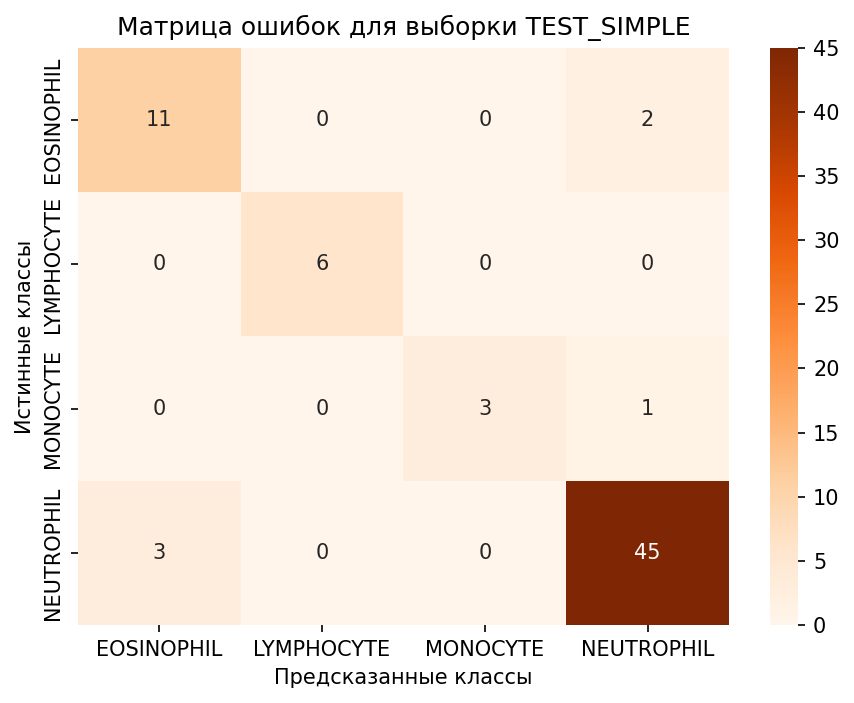

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix

# 1. Подгружаем наши самые лучшие веса (87.94%)
model.load_state_dict(torch.load("weights/best_blood_resnet50.pth", map_location=device))
model.eval()

simple_preds = []
simple_labels = []

print("🔄 Анализ картинок из TEST_SIMPLE...")

with torch.no_grad():
    for inputs, labels in simple_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        simple_preds.extend(preds.cpu().numpy())
        simple_labels.extend(labels.numpy())

# 2. Расчет метрик
correct = sum(np.array(simple_preds) == np.array(simple_labels))
simple_acc = correct / len(simple_labels)
simple_f1 = f1_score(simple_labels, simple_preds, average='weighted')

print(f"\n🎯 ТОЧНОСТЬ (Accuracy) НА TEST_SIMPLE: {simple_acc * 100:.2f}%")
print(f"📊 Метрика F1-Score (Weighted): {simple_f1:.4f}")

# 3. Построение матрицы ошибок
cm_simple = confusion_matrix(simple_labels, simple_preds)

plt.figure(figsize=(7, 5), dpi=150)
sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Oranges', # Сделаем оранжевой для отличия
            xticklabels=simple_dataset.classes, 
            yticklabels=simple_dataset.classes)

plt.title('Матрица ошибок для выборки TEST_SIMPLE')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')

# Сохраняем как отдельную картинку (пригодится для отчета или доп. аналитики)
plt.savefig('weights/confusion_matrix_simple.png', bbox_inches='tight')
print("💾 График сохранен в 'weights/confusion_matrix_simple.png'")

plt.show()
